In [1]:
import os

# Guardar modelos en carpeta del proyecto:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
os.environ["HF_HOME"] = os.path.join(PROJECT_ROOT, ".hf_cache")

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    ViTForImageClassification,
    ViTImageProcessor,
    ViTModel,
    CLIPModel,
    CLIPProcessor,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def download_image(url):
    """Descarga imagen desde URL y la convierte a RGB."""
    headers = {"User-Agent": "Mozilla/5.0"}
    return Image.open(BytesIO(requests.get(url, headers=headers).content)).convert("RGB")

def plot_horizontal_bars(ax, labels, values, title=None, xlim=1.0):
    """Grafica barras horizontales con etiquetas."""
    ax.barh(range(len(labels)), values)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlim(0, xlim)
    ax.invert_yaxis()
    if title:
        ax.set_title(title)

# Arquitecturas tipo Transformer

## BERT

### Masked Language Model

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 7770.51it/s]


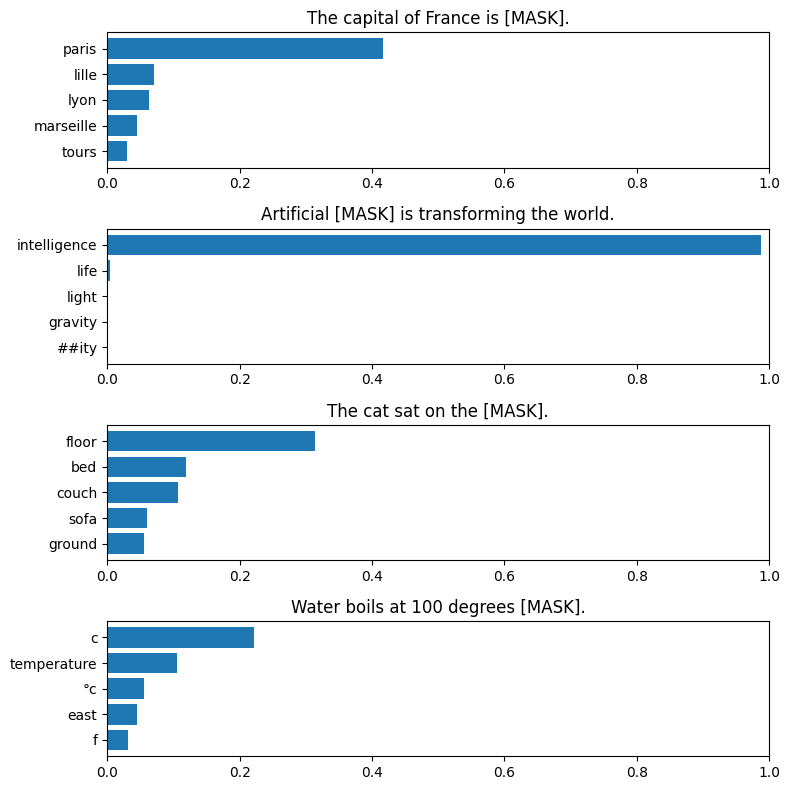

In [2]:
# Pipeline retorna lista de dicts: [{'token_str': str, 'score': float, 'token': int, 'sequence': str}, ...]
fill_mask = pipeline("fill-mask", model="bert-base-uncased", device=DEVICE)

sentences = [
    "The capital of France is [MASK].",
    "Artificial [MASK] is transforming the world.",
    "The cat sat on the [MASK].",
    "Water boils at 100 degrees [MASK].",
]

fig, axes = plt.subplots(len(sentences), 1, figsize=(8, 2 * len(sentences)))

for ax, sentence in zip(axes, sentences):
    results = fill_mask(sentence)[:5]
    tokens = [r["token_str"] for r in results]
    scores = [r["score"] for r in results]
    plot_horizontal_bars(ax, tokens, scores, title=sentence)

plt.tight_layout()
plt.show()

### Clasificación de Secuencias

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7214.91it/s]


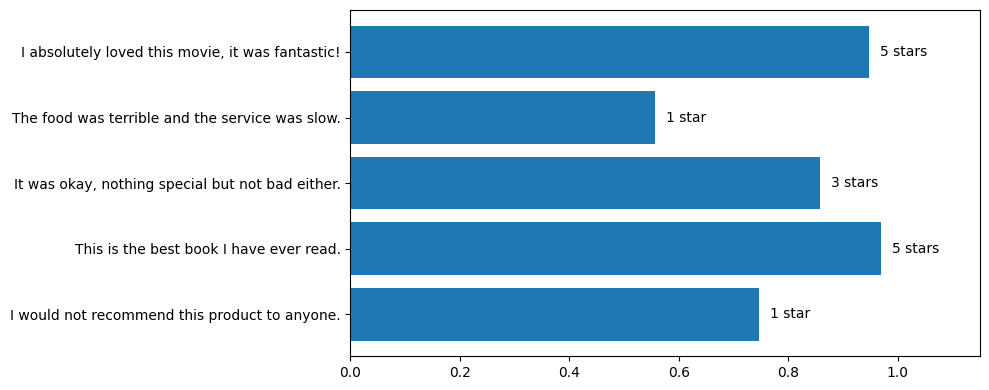

In [3]:
# Pipeline retorna lista con un dict: [{'label': '5 stars', 'score': float}]
classifier = pipeline(
    "text-classification",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=DEVICE,
)

texts = [
    "I absolutely loved this movie, it was fantastic!",
    "The food was terrible and the service was slow.",
    "It was okay, nothing special but not bad either.",
    "This is the best book I have ever read.",
    "I would not recommend this product to anyone.",
]

# Clasificar cada texto
results = [classifier(t)[0] for t in texts]

fig, ax = plt.subplots(figsize=(10, 4))
scores = [r["score"] for r in results]
labels = [t[:50] + "..." if len(t) > 50 else t for t in texts]
bars = ax.barh(range(len(texts)), scores)
ax.set_yticks(range(len(texts)))
ax.set_yticklabels(labels)
ax.set_xlim(0, 1.15)
ax.invert_yaxis()

# Agregar etiquetas de estrellas
for i, (bar, r) in enumerate(zip(bars, results)):
    ax.text(bar.get_width() + 0.02, i, r["label"], va="center")

plt.tight_layout()
plt.show()

### Extracción de Subsecuencias

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5617.66it/s]


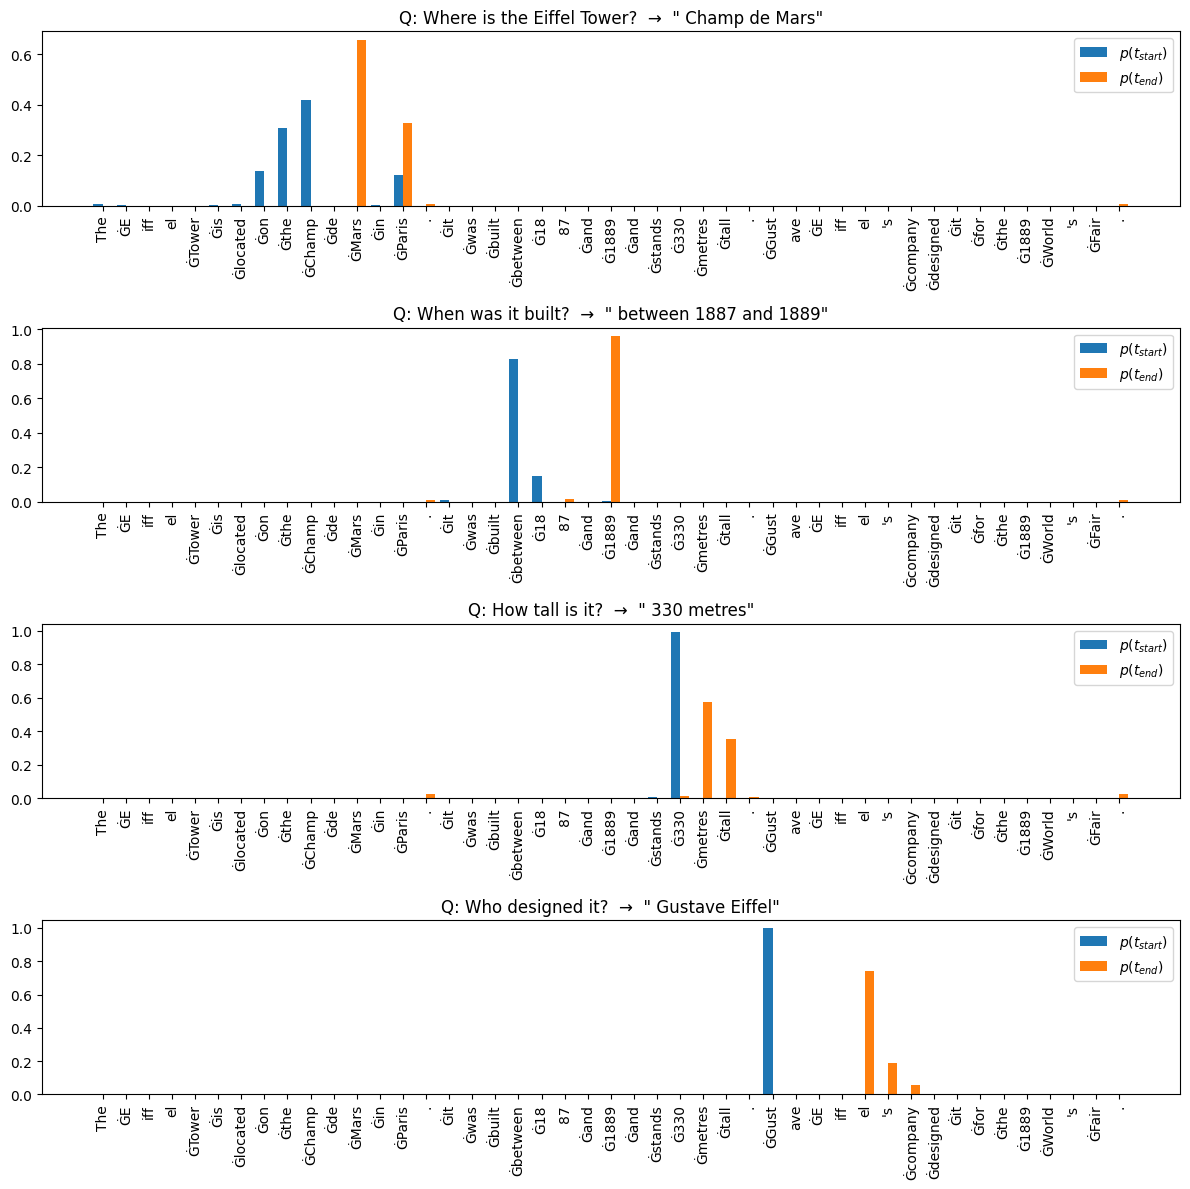

In [4]:
qa_model_name = "deepset/roberta-base-squad2"
qa_tokenizer = AutoTokenizer.from_pretrained(qa_model_name)
qa_model = AutoModelForQuestionAnswering.from_pretrained(qa_model_name).to(DEVICE)

context = (
    "The Eiffel Tower is located on the Champ de Mars in Paris. "
    "It was built between 1887 and 1889 and stands 330 metres tall. "
    "Gustave Eiffel's company designed it for the 1889 World's Fair."
)

questions = [
    "Where is the Eiffel Tower?",
    "When was it built?",
    "How tall is it?",
    "Who designed it?",
]

fig, axes = plt.subplots(len(questions), 1, figsize=(12, 3 * len(questions)))

for ax, question in zip(axes, questions):
    inputs = qa_tokenizer(question, context, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        # outputs: QuestionAnsweringModelOutput con start_logits y end_logits (shape: [1, seq_len])
        outputs = qa_model(**inputs)

    # Encontrar posiciones de inicio y fin con mayor probabilidad
    start_idx = outputs.start_logits.argmax().item()
    end_idx = outputs.end_logits.argmax().item()
    answer = qa_tokenizer.decode(inputs["input_ids"][0, start_idx:end_idx + 1])

    # Extraer solo tokens del contexto
    # RoBERTa tokeniza: <s> pregunta </s> </s> contexto </s>
    tokens = qa_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    sep_positions = [i for i, t in enumerate(tokens) if t == "</s>"]
    ctx_start = sep_positions[1] + 1  # Después del segundo </s>
    ctx_end = sep_positions[2] if len(sep_positions) > 2 else len(tokens)  # Antes del último </s>
    ctx_tokens = tokens[ctx_start:ctx_end]
    n = len(ctx_tokens)

    # Probabilidades sobre tokens del contexto
    start_probs = torch.softmax(outputs.start_logits[0, ctx_start:ctx_start + n], dim=-1).cpu().numpy()
    end_probs = torch.softmax(outputs.end_logits[0, ctx_start:ctx_start + n], dim=-1).cpu().numpy()

    # Visualizar
    x = np.arange(n)
    ax.bar(x - 0.2, start_probs, width=0.4, label="$p(t_{start})$")
    ax.bar(x + 0.2, end_probs, width=0.4, label="$p(t_{end})$")
    ax.set_xticks(x)
    ax.set_xticklabels(ctx_tokens, rotation=90)
    ax.set_title(f'Q: {question}  →  "{answer}"')
    ax.legend()

plt.tight_layout()
plt.show()

## Vision Transformer (ViT)

### Clasificación de Imágenes

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 7518.22it/s]


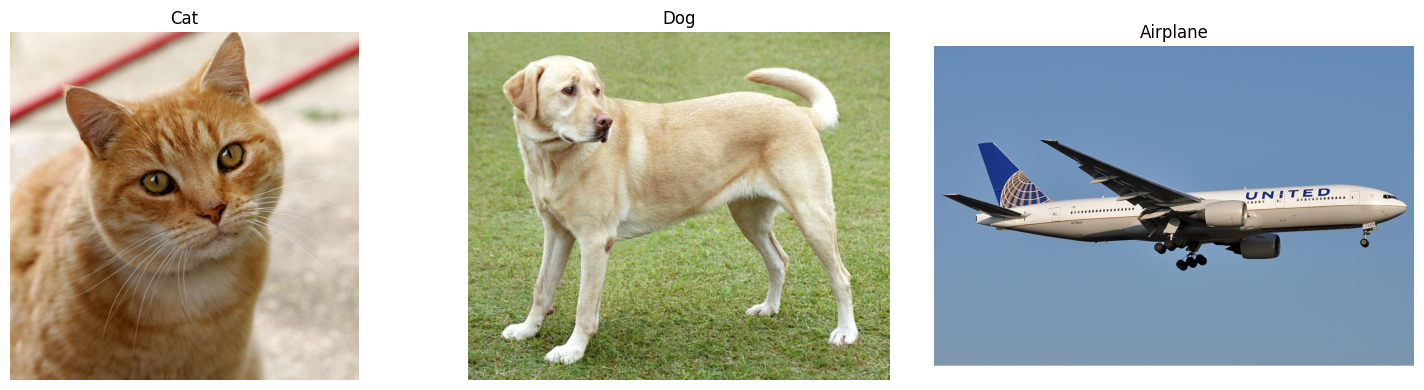

In [5]:
vit_model_name = "google/vit-base-patch16-224"
vit_processor = ViTImageProcessor.from_pretrained(vit_model_name)
vit_model = ViTForImageClassification.from_pretrained(vit_model_name).to(DEVICE)

image_urls = {
    "Cat": "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg",
    "Dog": "https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/1200px-YellowLabradorLooking_new.jpg",
    "Airplane": "https://upload.wikimedia.org/wikipedia/commons/3/36/United_Airlines_Boeing_777-200_Meulemans.jpg",
}

images = {name: download_image(url) for name, url in image_urls.items()}

# Mostrar imágenes
fig, axes = plt.subplots(1, len(images), figsize=(15, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

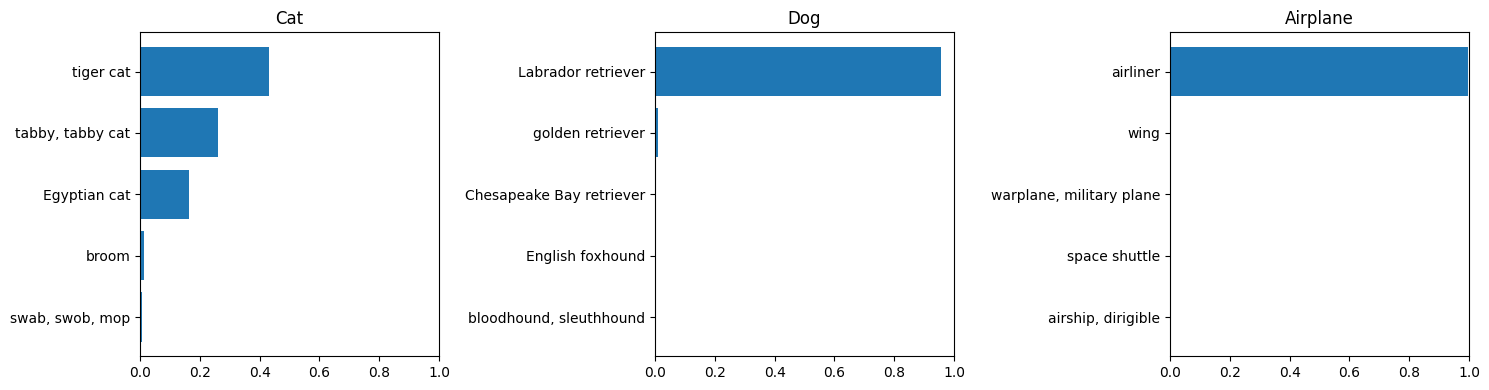

In [6]:
fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 4))

for ax, (name, img) in zip(axes, images.items()):
    inputs = vit_processor(images=img, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        # outputs: ImageClassifierOutput con logits (shape: [1, 1000] para ImageNet)
        logits = vit_model(**inputs).logits

    # Top-5 predicciones
    probs = torch.softmax(logits, dim=-1)
    top5_probs, top5_ids = probs[0].topk(5)
    labels = [vit_model.config.id2label[i.item()] for i in top5_ids]
    values = top5_probs.cpu().numpy()

    plot_horizontal_bars(ax, labels, values, title=name)

plt.tight_layout()
plt.show()

### Visualización de Atención

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 18671.95it/s]


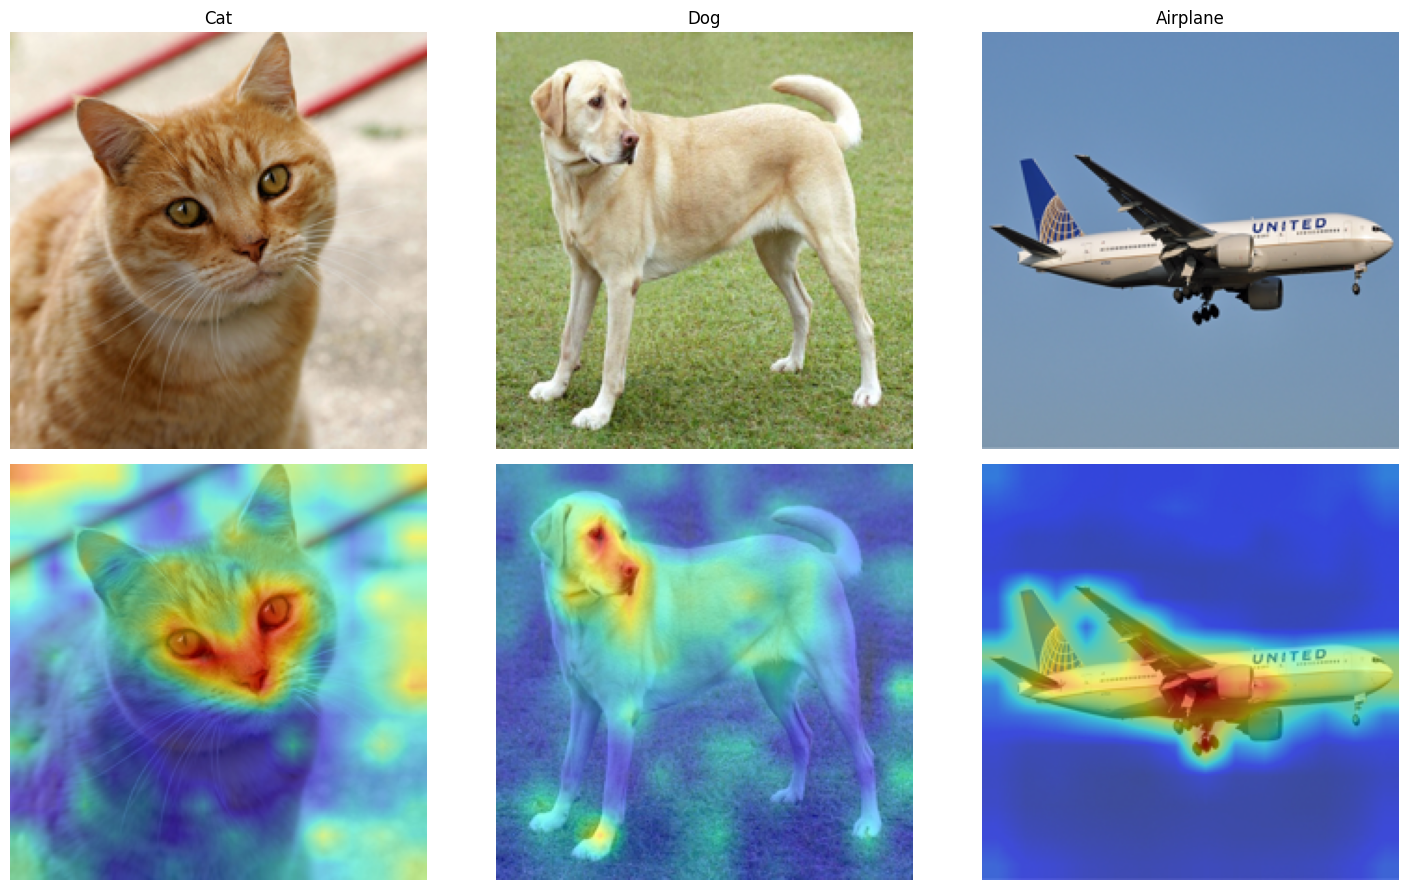

In [7]:
# outputs: BaseModelOutputWithPooling con attentions (tupla de tensores [batch, heads, seq, seq])
vit_base = ViTModel.from_pretrained(vit_model_name, output_attentions=True).to(DEVICE)

def attention_rollout(attentions):
    """Calcula attention rollout desde [CLS] hacia cada patch."""
    device = attentions[0].device
    n = attentions[0].shape[-1]
    result = torch.eye(n, device=device)

    for attn in attentions:
        # Promedio sobre cabezales + conexión residual
        attn_avg = attn[0].mean(dim=0)
        attn_res = 0.5 * attn_avg + 0.5 * torch.eye(n, device=device)
        attn_res = attn_res / attn_res.sum(dim=-1, keepdim=True)
        result = attn_res @ result

    return result[0, 1:]  # Atención de [CLS] hacia patches

def visualize_attention(img, attentions, size=224):
    """Genera mapa de atención sobre imagen."""
    mask = attention_rollout(attentions)
    n_patches = int(mask.shape[0] ** 0.5)
    mask = mask.reshape(1, 1, n_patches, n_patches).float()
    mask = F.interpolate(mask, size=(size, size), mode="bilinear", align_corners=False)[0, 0]
    mask = mask.cpu().numpy()
    return (mask - mask.min()) / (mask.max() - mask.min())

fig, axes = plt.subplots(2, len(images), figsize=(5 * len(images), 9))

for col, (name, img) in enumerate(images.items()):
    inputs = vit_processor(images=img, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = vit_base(**inputs)

    mask = visualize_attention(img, outputs.attentions)
    img_resized = img.resize((224, 224))

    # Imagen original
    axes[0, col].imshow(img_resized)
    axes[0, col].set_title(name)
    axes[0, col].axis("off")

    # Imagen con atención
    axes[1, col].imshow(img_resized)
    axes[1, col].imshow(mask, cmap="jet", alpha=0.5)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## CLIP

### Similitud Imagen-Texto

In [8]:
clip_model_name = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)
clip_model = CLIPModel.from_pretrained(clip_model_name).to(DEVICE)

# Reusar imágenes de ViT
clip_images = list(images.values())
image_names = list(images.keys())

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 46697.24it/s]


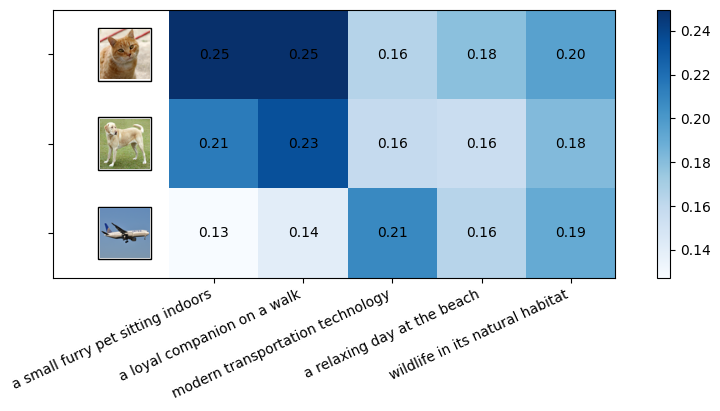

In [9]:
descriptions = [
    "a small furry pet sitting indoors",
    "a loyal companion on a walk",
    "modern transportation technology",
    "a relaxing day at the beach",
    "wildlife in its natural habitat",
]

inputs = clip_processor(
    text=descriptions, images=clip_images, return_tensors="pt", padding=True
).to(DEVICE)

with torch.no_grad():
    # outputs: CLIPOutput con image_embeds [n_imgs, D] y text_embeds [n_texts, D]
    outputs = clip_model(**inputs)

# Normalizar y calcular similitud coseno
image_embeds = F.normalize(outputs.image_embeds, dim=-1)
text_embeds = F.normalize(outputs.text_embeds, dim=-1)
similarity = (image_embeds @ text_embeds.T).cpu().numpy()

# Visualizar matriz de similitud
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(similarity, cmap="Blues")

n_imgs, n_texts = similarity.shape

# Anotar valores
for i in range(n_imgs):
    for j in range(n_texts):
        ax.text(j, i, f"{similarity[i, j]:.2f}", ha="center", va="center")

ax.set_xticks(range(n_texts))
ax.set_xticklabels(descriptions, rotation=25, ha="right")
ax.set_yticks(range(n_imgs))
ax.set_yticklabels([""] * n_imgs)

# Agregar thumbnails
for i, img in enumerate(clip_images):
    thumb = np.array(img.resize((60, 60)))
    ab = AnnotationBbox(OffsetImage(thumb, zoom=0.6), (-1, i), frameon=True, pad=0.1)
    ax.add_artist(ab)

ax.set_xlim(-1.8, n_texts - 0.5)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Clasificación Zero-Shot

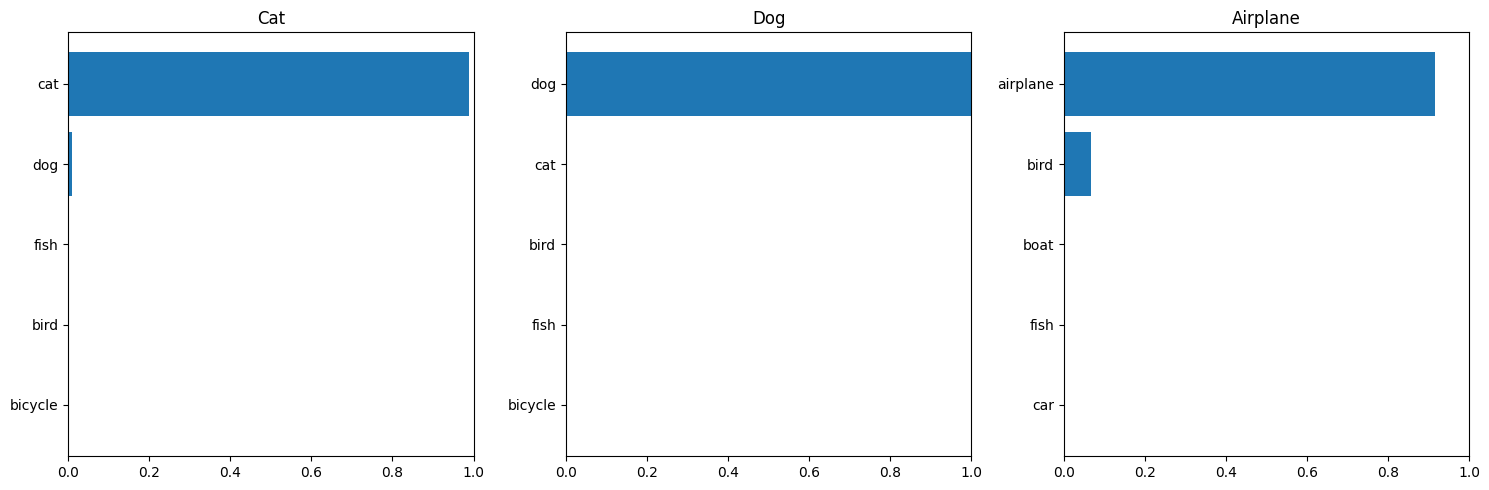

In [10]:
categories = [
    "cat", "dog", "bird", "fish",
    "airplane", "car", "bicycle", "boat",
    "house", "tree", "flower", "mountain",
]

category_texts = [f"a photo of a {c}" for c in categories]

fig, axes = plt.subplots(1, len(clip_images), figsize=(5 * len(clip_images), 5))

for ax, (name, img) in zip(axes, images.items()):
    inputs = clip_processor(
        text=category_texts, images=img, return_tensors="pt", padding=True
    ).to(DEVICE)

    with torch.no_grad():
        # logits_per_image: [1, n_categories], similitud escalada por temperatura
        logits = clip_model(**inputs).logits_per_image[0]

    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    top5_idx = probs.argsort()[-5:][::-1]
    top5_labels = [categories[i] for i in top5_idx]
    top5_probs = probs[top5_idx]

    plot_horizontal_bars(ax, top5_labels, top5_probs, title=name)

plt.tight_layout()
plt.show()

### Búsqueda Text-to-Image

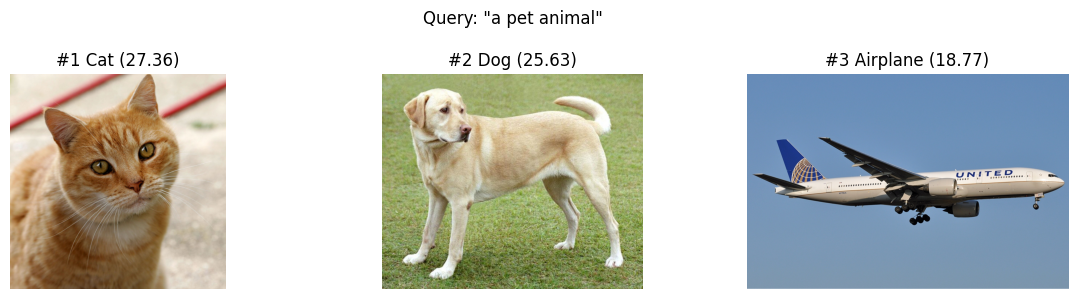

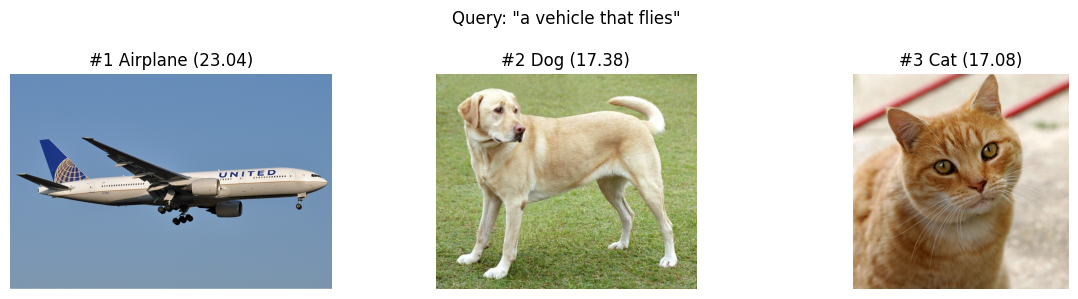

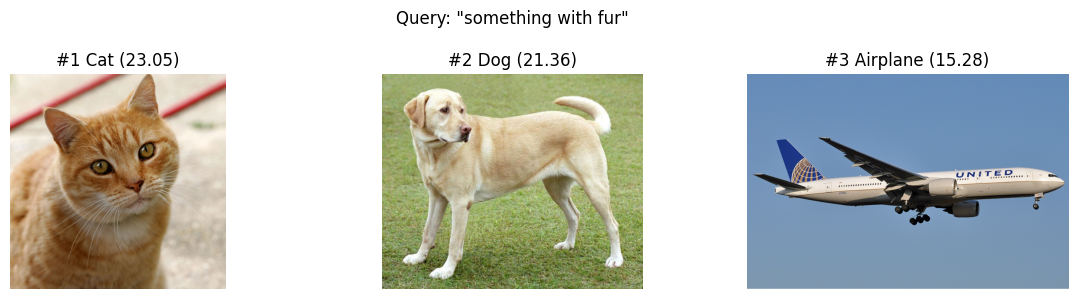

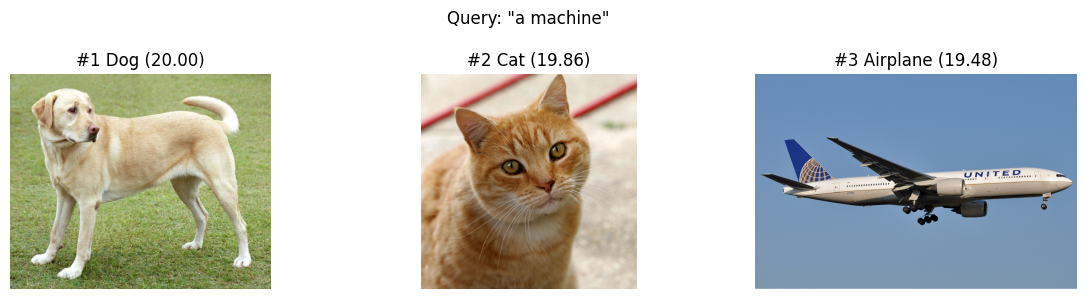

In [11]:
queries = [
    "a pet animal",
    "a vehicle that flies",
    "something with fur",
    "a machine",
]

for query in queries:
    inputs = clip_processor(
        text=[query], images=clip_images, return_tensors="pt", padding=True
    ).to(DEVICE)

    with torch.no_grad():
        # logits_per_text: [1, n_images], similitud de texto con cada imagen
        sims = clip_model(**inputs).logits_per_text[0].cpu().numpy()

    # Ordenar por similitud
    order = sims.argsort()[::-1]

    fig, axes = plt.subplots(1, len(clip_images), figsize=(4 * len(clip_images), 3))
    fig.suptitle(f'Query: "{query}"')

    for rank, idx in enumerate(order):
        axes[rank].imshow(clip_images[idx])
        axes[rank].set_title(f"#{rank + 1} {image_names[idx]} ({sims[idx]:.2f})")
        axes[rank].axis("off")

    plt.tight_layout()
    plt.show()